# Signals
## Key Concepts 
- Sampling and Aliasing
- Fourier Transform (FFT)
- Filtering (Low-pass, High-pass)
- Convolution and Correlation
- Spectrograms and Time-Frequency Analysis


## Practical Applications:
- Denoising
- Signal compression
- Audio signal analysis


## Module 1: Introduction to Signals
A signal is a function that conveys information.

Common types:
- 1D Signal: Audio signals, ECG signals.
- 2D Signal: Images (2D array of pixel intensities).

### Continuous vs Discrete Signals
- Continuous: Infinite points (real-world signals like sound, ECG).
- Discrete: Sampled version of continuous signals (e.g., digital audio).
 
In signal processing, we often work with discrete signals — sequences of numbers sampled from continuous signals.

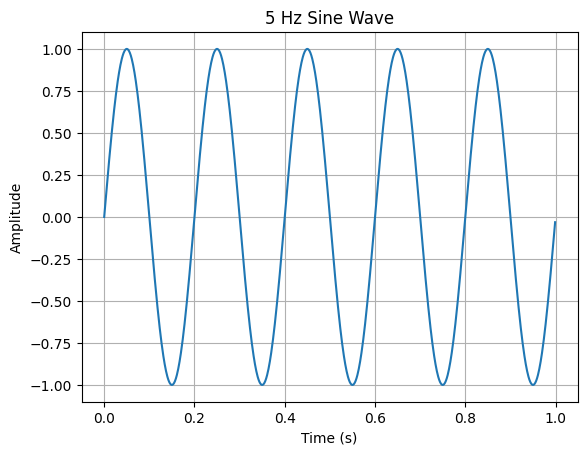

In [1]:
# Let’s create a simple sine wave.
import numpy as np
import matplotlib.pyplot as plt

# Signal parameters
fs = 1000  # Sampling frequency (Hz)
t = np.linspace(0, 1, fs, endpoint=False)  # Time vector
f = 5  # Frequency of the sine wave (Hz)

# Generate the signal
signal = np.sin(2 * np.pi * f * t)

# Plot the signal
plt.plot(t, signal)
plt.title('5 Hz Sine Wave')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

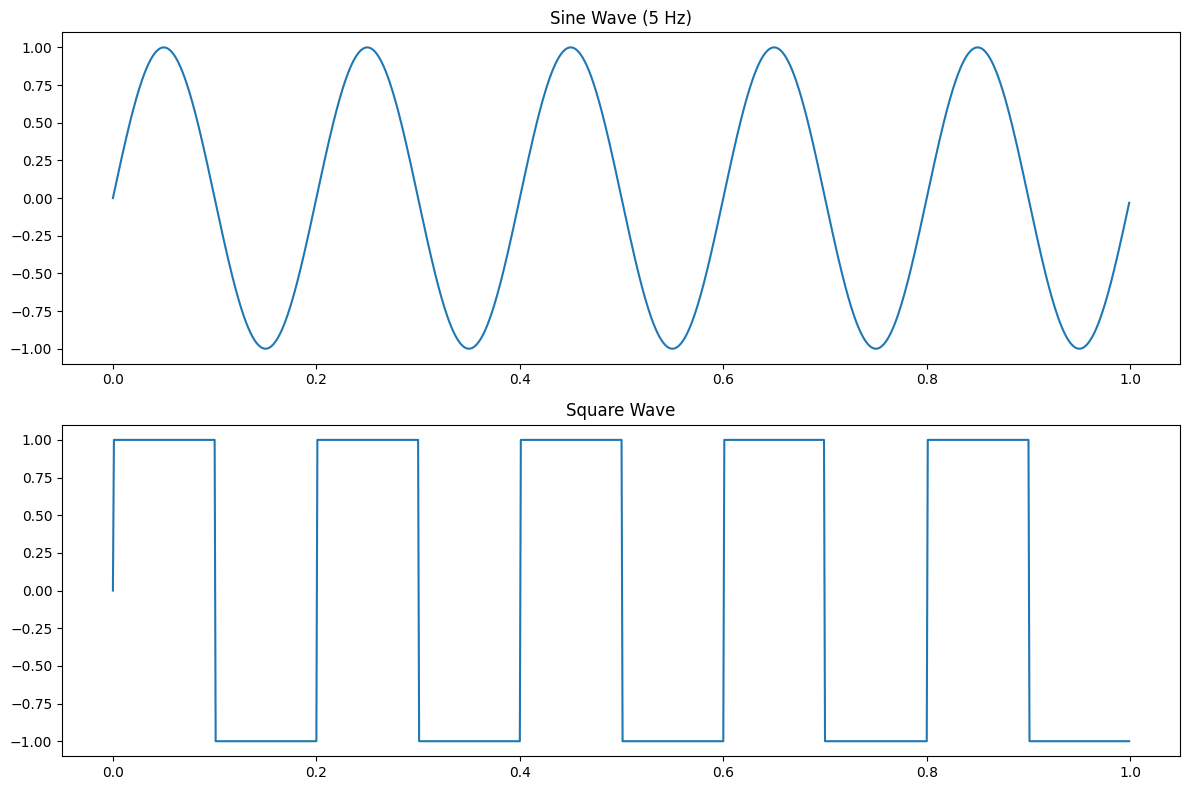

In [4]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1000  # Sampling frequency in Hz
t = np.linspace(0, 1, fs, endpoint=False)  # 1 second of time

# Sine wave
f_sine = 5
sine_wave = np.sin(2 * np.pi * f_sine * t)

# Square wave
square_wave = np.sign(sine_wave)

# Plotting
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t, sine_wave)
plt.title("Sine Wave (5 Hz)")

plt.subplot(2, 1, 2)
plt.plot(t, square_wave)
plt.title("Square Wave")

plt.tight_layout()
plt.show()


# Module 2: Sampling and Aliasing

### Part 1: What is Sampling?
Sampling is the process of converting a continuous-time signal (analog) into a discrete-time signal (digital) by taking measurements at regular time intervals.

Key Term:
Sampling Rate (fs): Number of samples per second (in Hz)

### Part 2: Nyquist Theorem
To faithfully reconstruct a signal, it must be sampled at at least twice its highest frequency component.

This critical rate is called the Nyquist rate: Nyquist Rate = 2 × (Maximum frequency of the signal)

If you sample below the Nyquist rate, aliasing occurs.

### Part 3: Aliasing Explained
Aliasing is when different signals become indistinguishable (or “aliases” of each other) during sampling — resulting in distorted or misleading representations.


Python Example – Sampling and Aliasing
Let's sample the same sine wave at different rates to see what aliasing looks like.

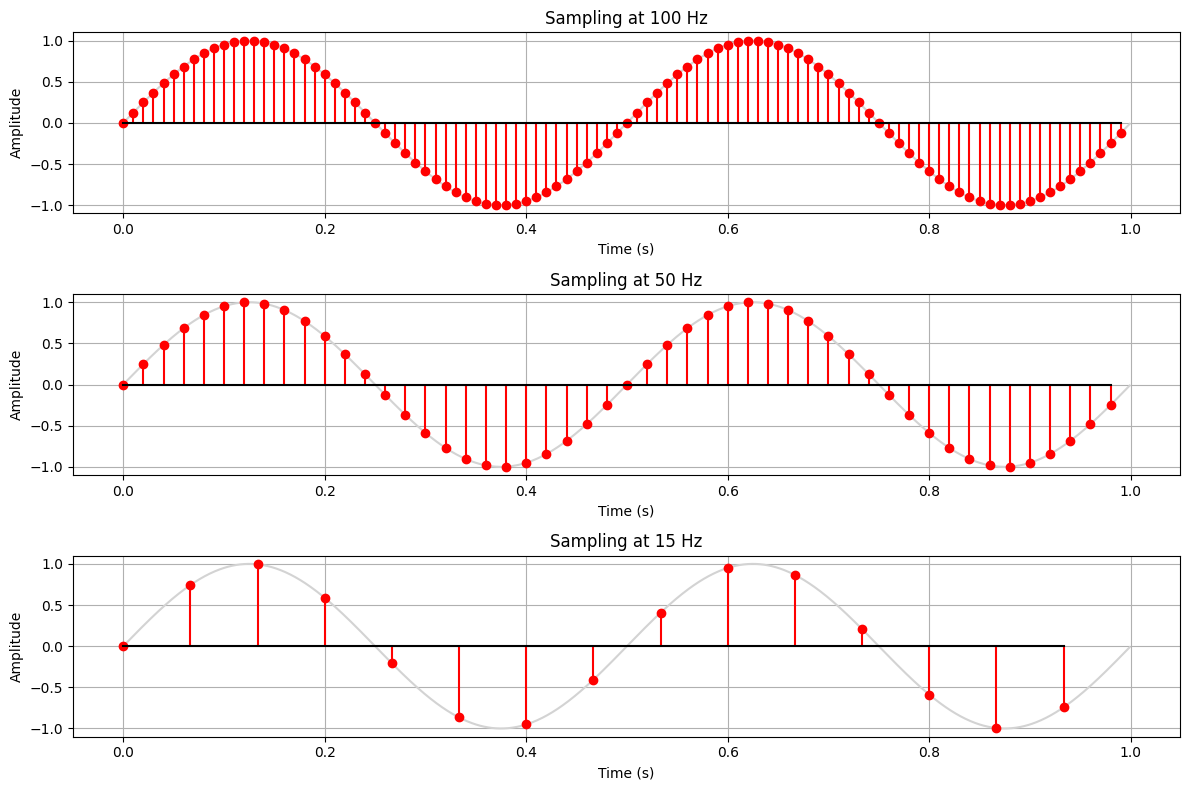

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Original continuous signal (reference)
f_signal = 2  # Frequency of the signal in Hz
t_cont = np.linspace(0, 1, 1000, endpoint=False)
signal_cont = np.sin(2 * np.pi * f_signal * t_cont)

# Sample at different rates
sampling_rates = [100, 50, 15]  # Hz

plt.figure(figsize=(12, 8))

for i, fs in enumerate(sampling_rates, 1):
    t_sampled = np.linspace(0, 1, fs, endpoint=False)
    sampled_signal = np.sin(2 * np.pi * f_signal * t_sampled)

    plt.subplot(3, 1, i)
    plt.plot(t_cont, signal_cont, label='Original Signal', color='lightgray')
    plt.stem(t_sampled, sampled_signal, linefmt='r-', markerfmt='ro', basefmt='k')
    plt.title(f'Sampling at {fs} Hz')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)

plt.tight_layout()
plt.show()


# Module 3: Fourier Transform and Frequency Domain
### Part 1: Why Use the Fourier Transform?
A signal contains information in the time domain, but many operations (like filtering) are easier in the frequency domain.

The Fourier Transform breaks down a signal into a sum of sine and cosine waves (frequencies).

### Part 2: Discrete Fourier Transform (DFT) and FFT
In digital signal processing:
- We use the Discrete Fourier Transform (DFT) for sampled signals
- The Fast Fourier Transform (FFT) is a fast algorithm to compute the DFT

Example – Applying FFT in Python
Let’s analyze a signal composed of two sine waves.

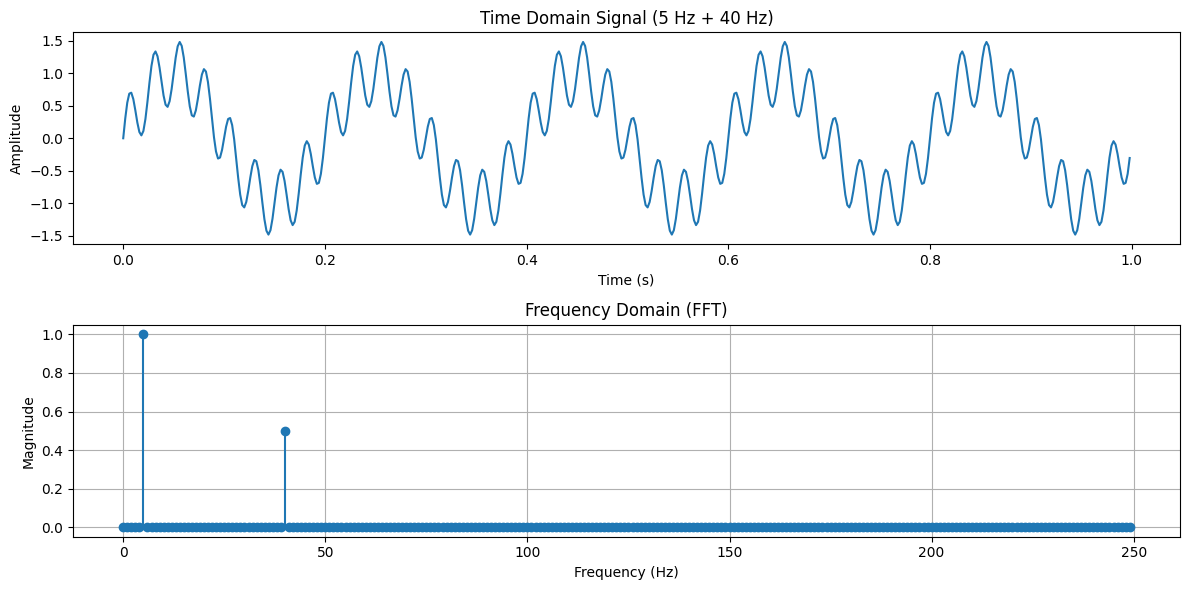

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Parameters
fs = 500  # Sampling frequency (Hz)
t = np.linspace(0, 1, fs, endpoint=False)

# Create signal: 5 Hz + 40 Hz
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 40 * t)

# Apply FFT
N = len(signal)
yf = fft(signal)  # Compute FFT
xf = fftfreq(N, 1/fs)  # Frequency bins

# Only take positive frequencies
xf = xf[:N//2]
yf = np.abs(yf[:N//2]) * 2 / N  # Normalize magnitude

# Plot time-domain
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title("Time Domain Signal (5 Hz + 40 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# Plot frequency-domain
plt.subplot(2, 1, 2)
plt.stem(xf, yf, basefmt=" ")  # Removed use_line_collection
plt.title("Frequency Domain (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)

plt.tight_layout()
plt.show()


### observation
- Time domain shows how a signal changes over time.
- Frequency domain shows which frequencies are present in the signal.

# Module 4: Filtering Techniques

### Part 1: What Is Filtering?
Filtering removes or enhances certain frequency components of a signal:

| Filter Type | What It Does                           |
| ----------- | -------------------------------------- |
| Low-pass    | Allows low frequencies, blocks high    |
| High-pass   | Allows high frequencies, blocks low    |
| Band-pass   | Allows a specific range of frequencies |
| Band-stop   | Blocks a specific range of frequencies |


### Part 2: Why Use Filters?
- Remove noise (high-frequency components)
- Focus on trends (low-frequency parts)
- Analyze specific frequency bands (like EEG or ECG)

### Part 3: Designing Filters in Python (Butterworth Example)
- We'll use scipy.signal.butter and scipy.signal.filtfilt.
- butter_filter() is a generic function that works for all filter types.

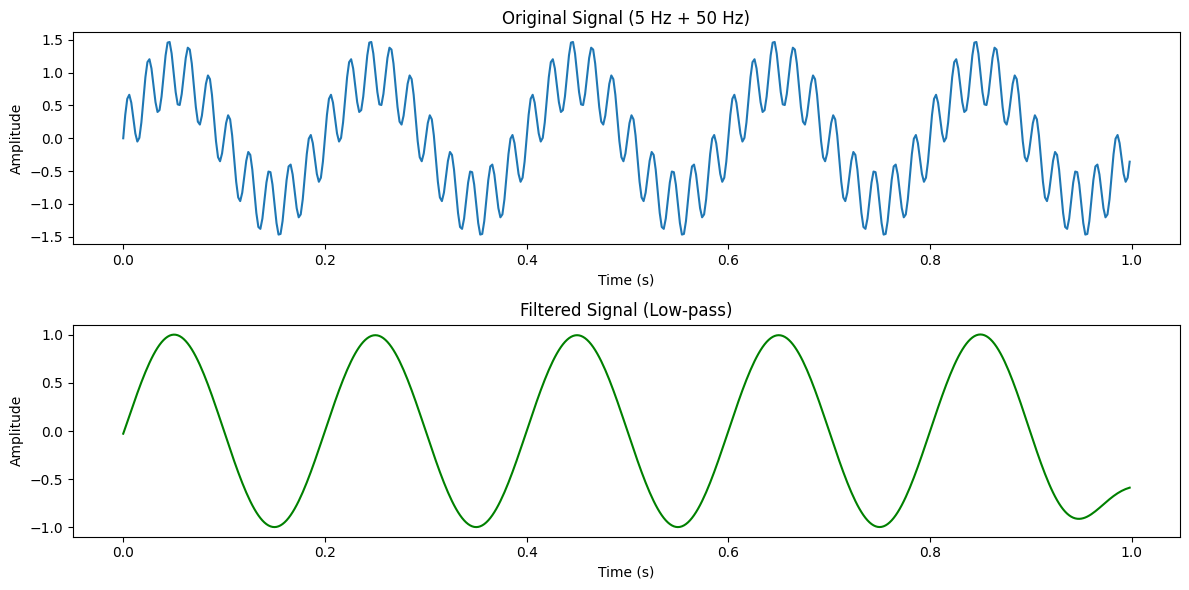

In [13]:
# Following demonstrates low-pass 

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Sampling setup
fs = 500  # Hz
t = np.linspace(0, 1, fs, endpoint=False)

# Signal: 5 Hz + 50 Hz
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 50 * t)

# --- Define Low-pass Filter ---
def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

# Apply filter
cutoff = 10  # Hz (keep up to 10 Hz)
b, a = butter_lowpass(cutoff, fs)
filtered_signal = filtfilt(b, a, signal)


# --- Plotting ---
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, signal, label='Original Signal')
plt.title("Original Signal (5 Hz + 50 Hz)")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(t, filtered_signal, color='green', label='Filtered (Low-pass <10 Hz)')
plt.title("Filtered Signal (Low-pass)")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


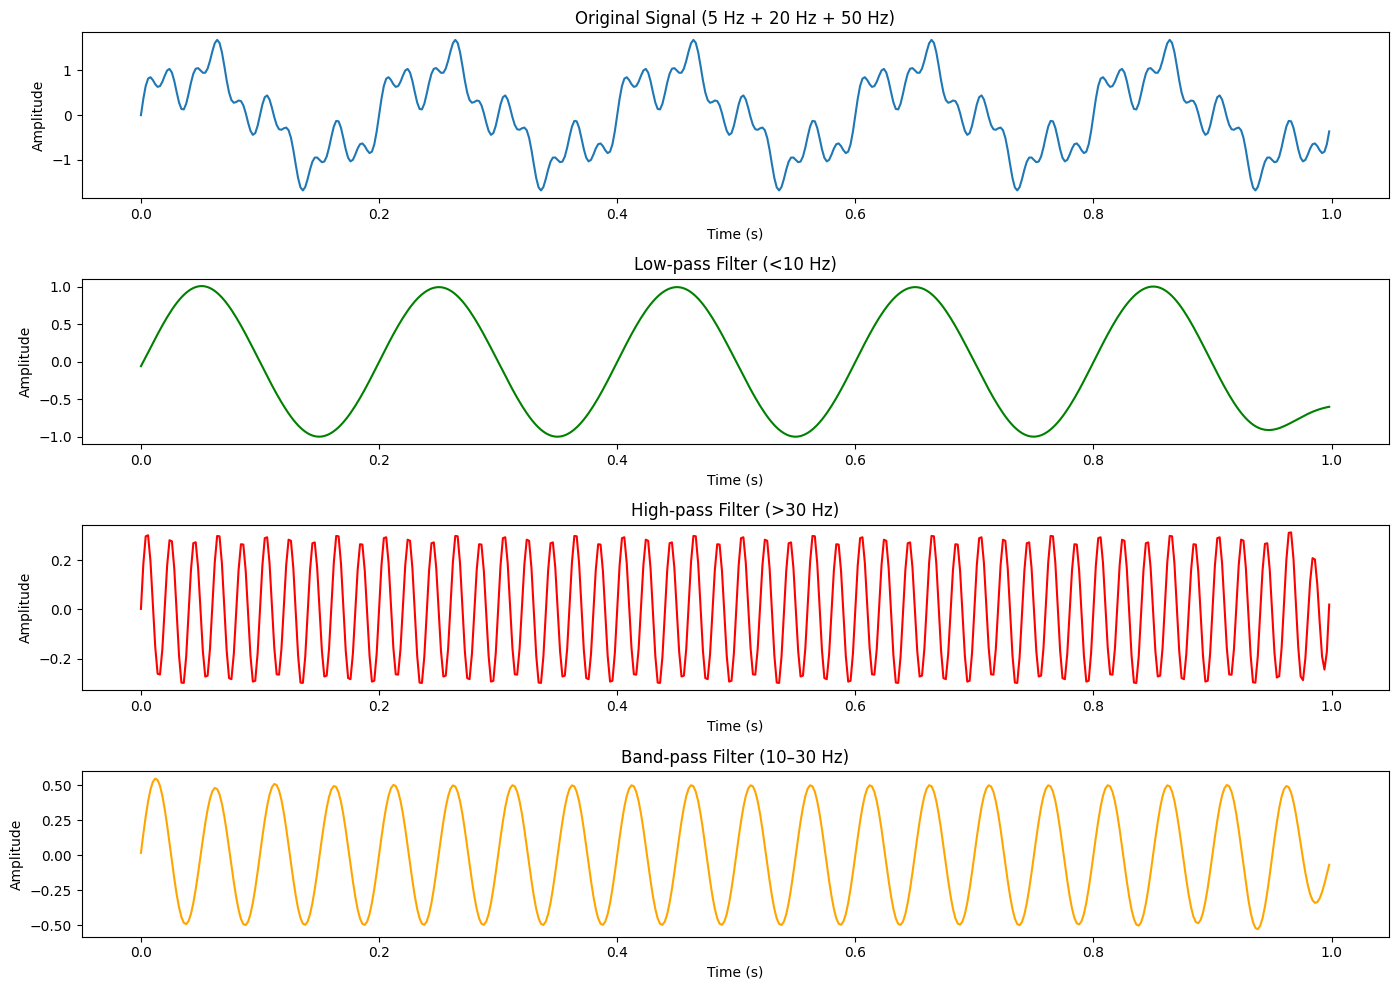

In [14]:
# Following demonstrates all three types of filters: low-pass, high-pass, and band-pass using 
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# Sampling setup
fs = 500  # Hz
t = np.linspace(0, 1, fs, endpoint=False)

# Signal = 5 Hz + 20 Hz + 50 Hz
signal = (
    np.sin(2 * np.pi * 5 * t) + 
    0.5 * np.sin(2 * np.pi * 20 * t) + 
    0.3 * np.sin(2 * np.pi * 50 * t)
)

# Filter helper function
def butter_filter(cutoff, fs, btype, order=4):
    nyq = 0.5 * fs
    if isinstance(cutoff, list):
        normal_cutoff = [f / nyq for f in cutoff]
    else:
        normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype=btype, analog=False)
    return b, a

# --- Apply Filters ---
# Low-pass filter (< 10 Hz)
b_lp, a_lp = butter_filter(10, fs, btype='low')
filtered_lp = filtfilt(b_lp, a_lp, signal)

# High-pass filter (> 30 Hz)
b_hp, a_hp = butter_filter(30, fs, btype='high')
filtered_hp = filtfilt(b_hp, a_hp, signal)

# Band-pass filter (10 Hz – 30 Hz)
b_bp, a_bp = butter_filter([10, 30], fs, btype='band')
filtered_bp = filtfilt(b_bp, a_bp, signal)

# --- Plotting ---
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(t, signal, label='Original Signal')
plt.title("Original Signal (5 Hz + 20 Hz + 50 Hz)")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")

plt.subplot(4, 1, 2)
plt.plot(t, filtered_lp, color='green', label='Low-pass <10 Hz')
plt.title("Low-pass Filter (<10 Hz)")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")

plt.subplot(4, 1, 3)
plt.plot(t, filtered_hp, color='red', label='High-pass >30 Hz')
plt.title("High-pass Filter (>30 Hz)")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")

plt.subplot(4, 1, 4)
plt.plot(t, filtered_bp, color='orange', label='Band-pass 10–30 Hz')
plt.title("Band-pass Filter (10–30 Hz)")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


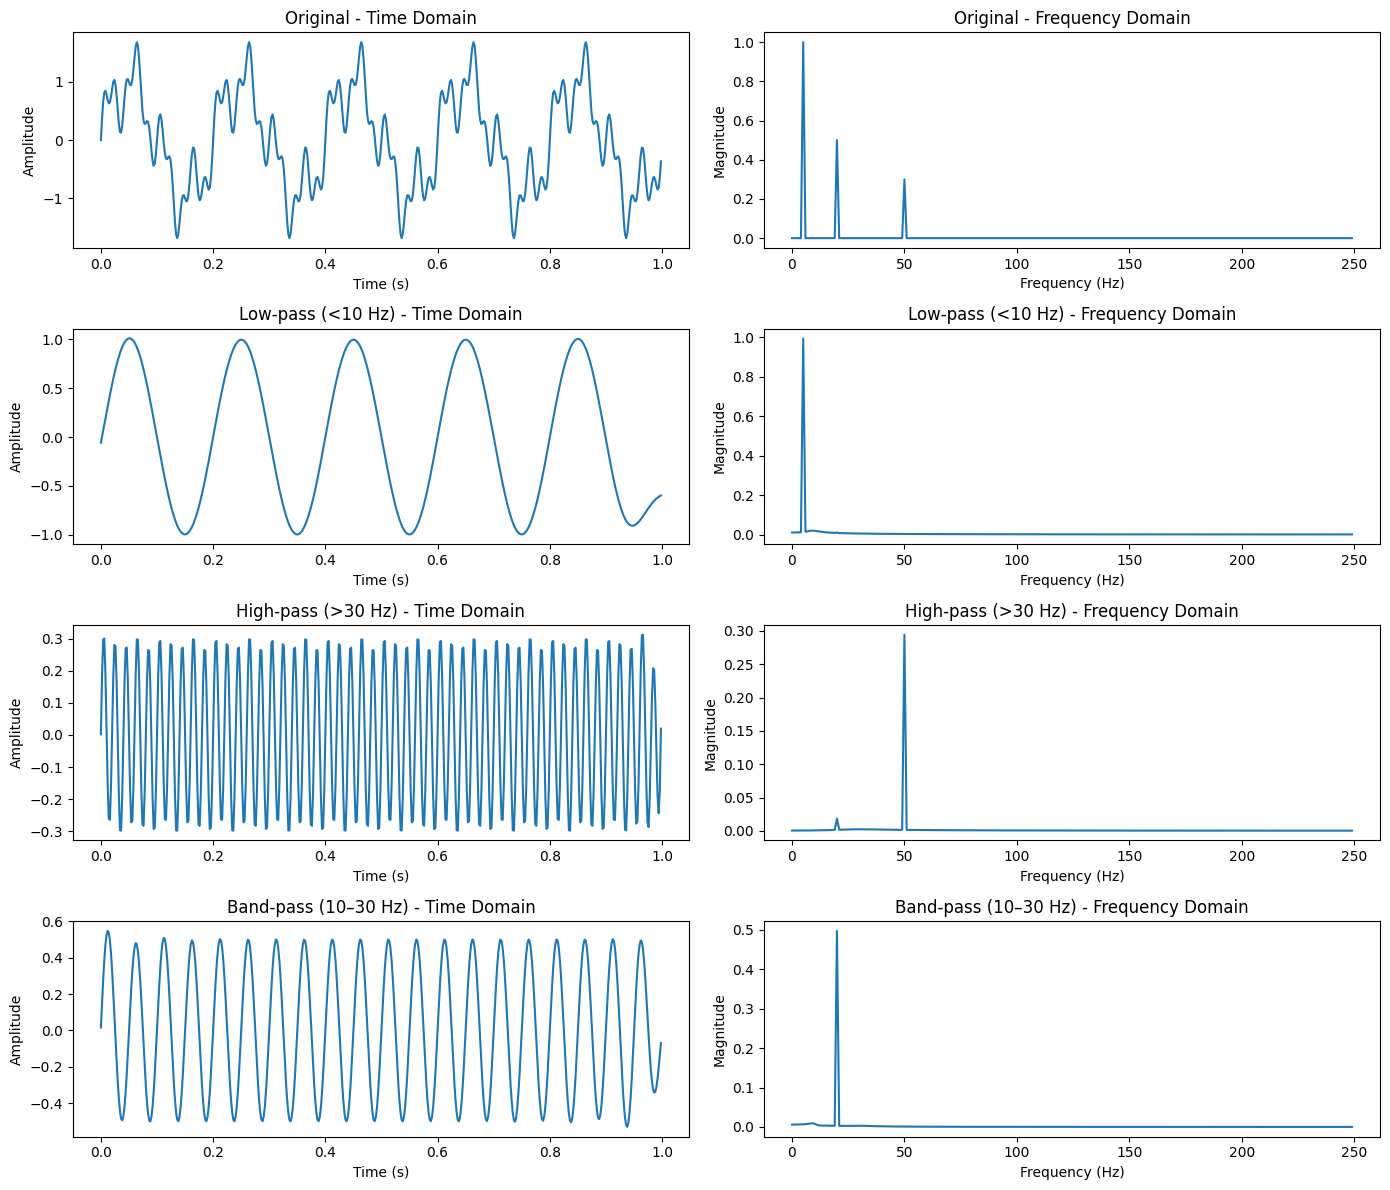

In [15]:
# Now I want to see FFT plots above too
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.fft import fft, fftfreq

# Sampling setup
fs = 500  # Hz
t = np.linspace(0, 1, fs, endpoint=False)

# Original Signal = 5 Hz + 20 Hz + 50 Hz
signal = (
    np.sin(2 * np.pi * 5 * t) + 
    0.5 * np.sin(2 * np.pi * 20 * t) + 
    0.3 * np.sin(2 * np.pi * 50 * t)
)

# --- Filter helper function ---
def butter_filter(cutoff, fs, btype, order=4):
    nyq = 0.5 * fs
    if isinstance(cutoff, list):
        normal_cutoff = [f / nyq for f in cutoff]
    else:
        normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype=btype, analog=False)
    return b, a

# --- Apply Filters ---
b_lp, a_lp = butter_filter(10, fs, btype='low')
filtered_lp = filtfilt(b_lp, a_lp, signal)

b_hp, a_hp = butter_filter(30, fs, btype='high')
filtered_hp = filtfilt(b_hp, a_hp, signal)

b_bp, a_bp = butter_filter([10, 30], fs, btype='band')
filtered_bp = filtfilt(b_bp, a_bp, signal)

# --- FFT Helper ---
def compute_fft(sig, fs):
    N = len(sig)
    yf = np.abs(fft(sig)) / N
    xf = fftfreq(N, 1/fs)[:N//2]
    return xf, 2 * yf[:N//2]  # 2x for single-sided spectrum

# --- Plotting Time and Frequency Domains ---
signals = {
    "Original": signal,
    "Low-pass (<10 Hz)": filtered_lp,
    "High-pass (>30 Hz)": filtered_hp,
    "Band-pass (10–30 Hz)": filtered_bp
}

plt.figure(figsize=(14, 12))
for i, (title, sig) in enumerate(signals.items(), 1):
    xf, yf = compute_fft(sig, fs)

    plt.subplot(4, 2, 2*i - 1)
    plt.plot(t, sig)
    plt.title(f"{title} - Time Domain")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude")

    plt.subplot(4, 2, 2*i)
    plt.plot(xf, yf)
    plt.title(f"{title} - Frequency Domain")
    plt.xlabel("Frequency (Hz)"); plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()


# Module 5: Convolution and Signal Smoothing
Key Concepts:
- Convolution is the process of applying a kernel/filter to a signal.
- Often used in signal smoothing (e.g. moving average), edge detection, or system response modeling.
- In Python, we use np.convolve() or scipy.signal.convolve.

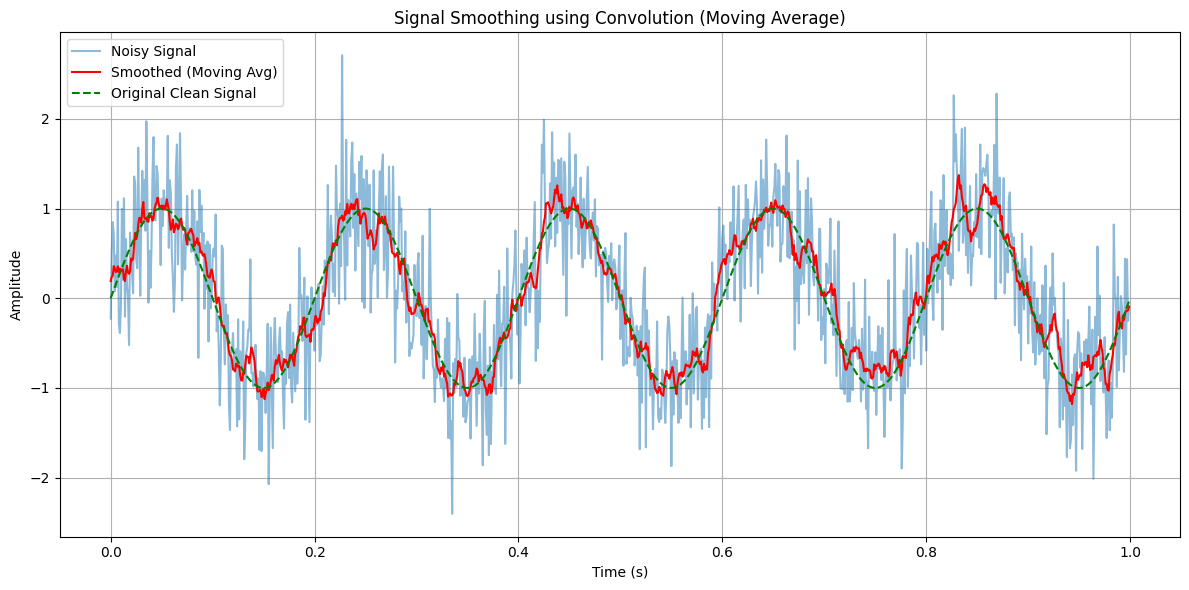

In [17]:
# Part 1: Simple Moving Average Smoothing
# We’ll apply a moving average filter (a basic smoothing filter) to a noisy signal.

import numpy as np
import matplotlib.pyplot as plt

# Generate clean sine signal
fs = 1000  # Sampling frequency
t = np.linspace(0, 1, fs, endpoint=False)
clean_signal = np.sin(2 * np.pi * 5 * t)  # 5 Hz sine wave

# Add Gaussian noise
noisy_signal = clean_signal + 0.5 * np.random.normal(size=t.shape)

# Define moving average filter (kernel)
kernel_size = 10
kernel = np.ones(kernel_size) / kernel_size

# Convolve signal with kernel
smoothed_signal = np.convolve(noisy_signal, kernel, mode='same')

# Plot
plt.figure(figsize=(12, 6))
plt.plot(t, noisy_signal, label='Noisy Signal', alpha=0.5)
plt.plot(t, smoothed_signal, label='Smoothed (Moving Avg)', color='red')
plt.plot(t, clean_signal, label='Original Clean Signal', linestyle='--', color='green')
plt.title("Signal Smoothing using Convolution (Moving Average)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


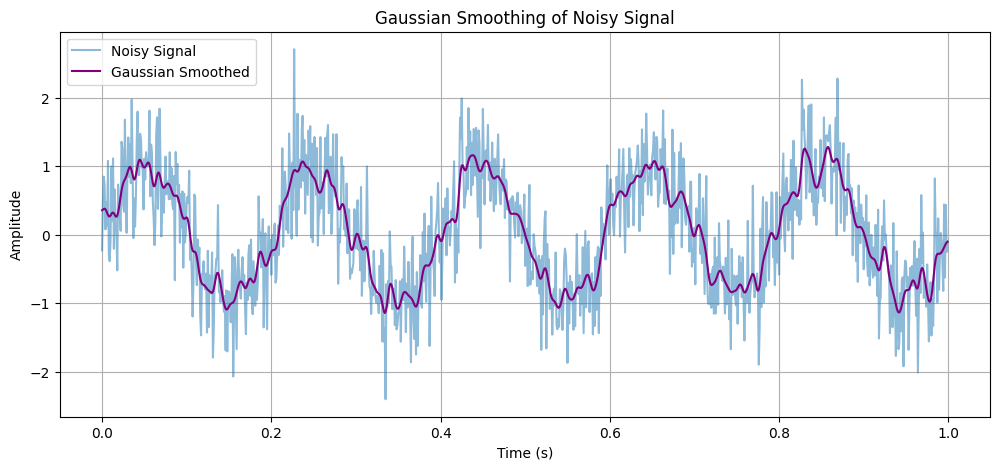

In [19]:
# Part 2: Using Gaussian Smoothing Kernel
# For more natural smoothing than a box (average) filter, use a Gaussian kernel:
from scipy.ndimage import gaussian_filter1d

# Apply Gaussian filter with sigma=3
gaussian_smoothed = gaussian_filter1d(noisy_signal, sigma=3)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(t, noisy_signal, label='Noisy Signal', alpha=0.5)
plt.plot(t, gaussian_smoothed, label='Gaussian Smoothed', color='purple')
plt.title("Gaussian Smoothing of Noisy Signal")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.legend(); plt.grid(True)
plt.show()



# Module 6: Windowing and Spectral Leakage
### Why Windowing?
When we perform an FFT on a finite-duration signal, we assume it's periodic. If the signal doesn’t complete an integer number of cycles, FFT introduces spectral leakage—spreading energy across frequencies.

### Goal:
See how a signal’s spectrum gets distorted due to spectral leakage

Apply window functions to reduce leakage

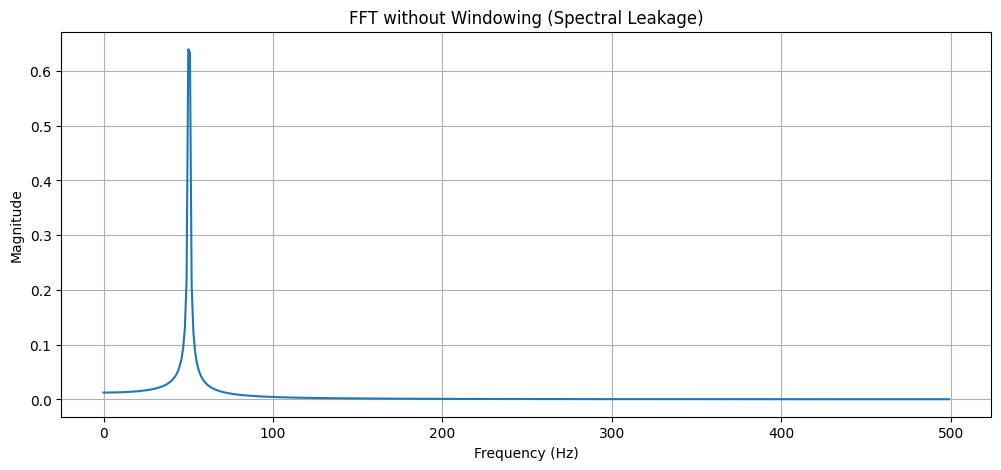

In [21]:
# Part 1: Spectral Leakage without Windowing

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Sampling setup
fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)

# A sine wave with non-integer number of cycles (e.g. 50.5 Hz)
f = 50.5
signal = np.sin(2 * np.pi * f * t)

# FFT
N = len(t)
xf = fftfreq(N, 1/fs)[:N//2]
yf = 2 * np.abs(fft(signal))[:N//2] / N

# Plot
plt.figure(figsize=(12, 5))
plt.plot(xf, yf)
plt.title("FFT without Windowing (Spectral Leakage)")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Magnitude")
plt.grid(True)
plt.show()


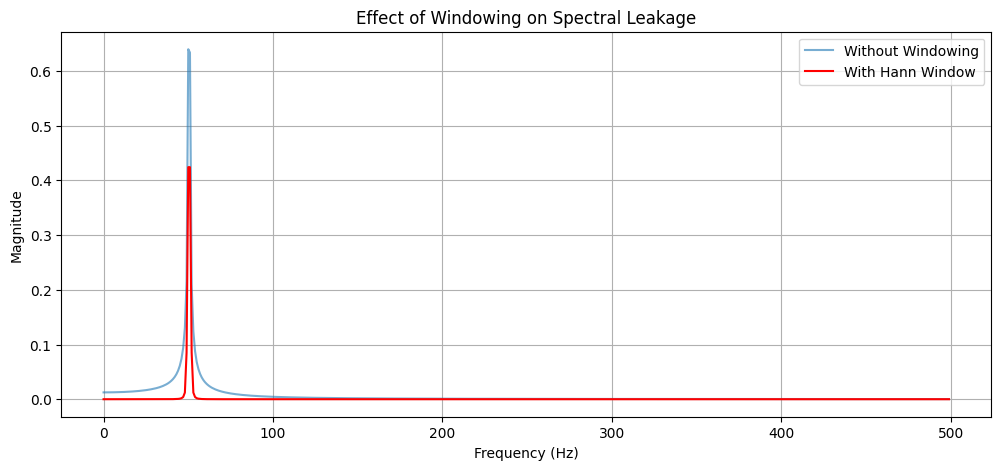

In [22]:
# Part 2: Apply a Window Function (Hann Window)
from scipy.signal.windows import hann

# Apply Hann window
window = hann(N)
windowed_signal = signal * window

# FFT of windowed signal
yf_win = 2 * np.abs(fft(windowed_signal))[:N//2] / N

# Plot comparison
plt.figure(figsize=(12, 5))
plt.plot(xf, yf, label="Without Windowing", alpha=0.6)
plt.plot(xf, yf_win, label="With Hann Window", color='red')
plt.title("Effect of Windowing on Spectral Leakage")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Magnitude")
plt.legend(); plt.grid(True)
plt.show()


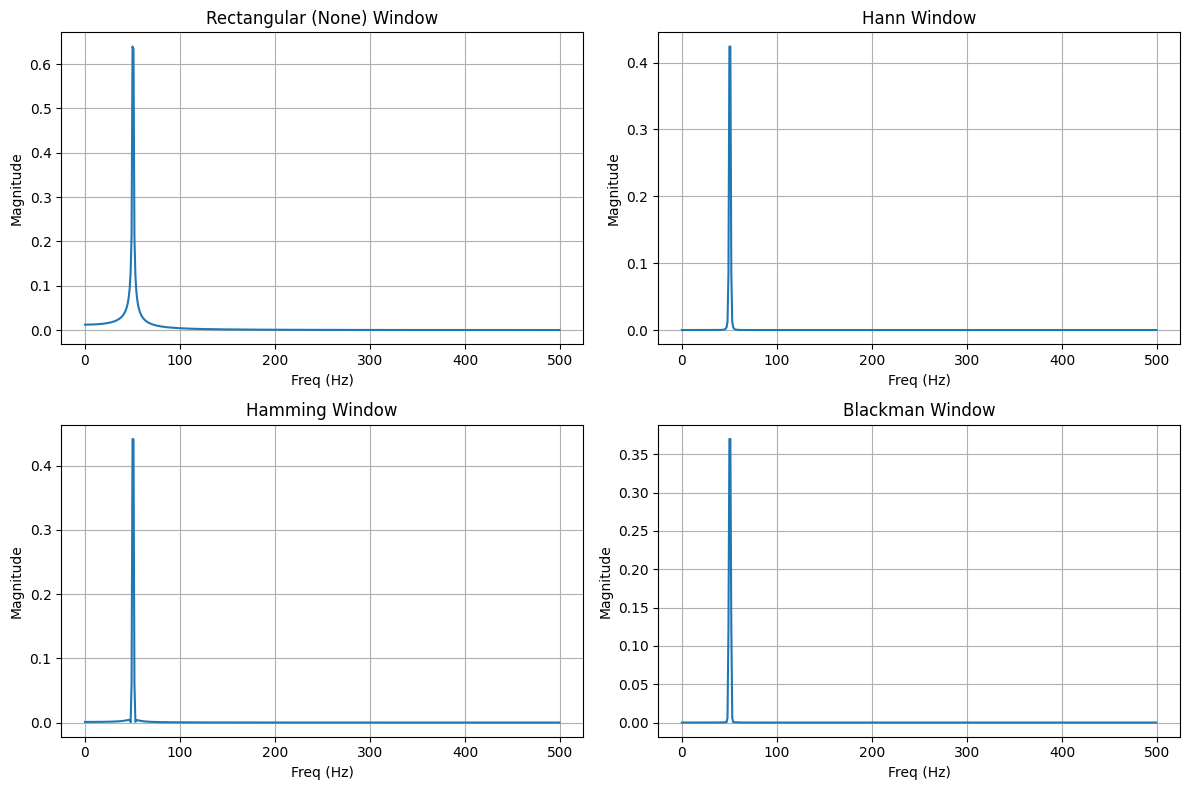

In [23]:
# Part 3: Try Other Windows (Optional)

from scipy.signal.windows import blackman, hamming

# Try different windows
windows = {
    "Rectangular (None)": np.ones(N),
    "Hann": hann(N),
    "Hamming": hamming(N),
    "Blackman": blackman(N),
}

plt.figure(figsize=(12, 8))

for i, (name, w) in enumerate(windows.items(), 1):
    win_sig = signal * w
    yf = 2 * np.abs(fft(win_sig))[:N//2] / N
    plt.subplot(2, 2, i)
    plt.plot(xf, yf)
    plt.title(f"{name} Window")
    plt.xlabel("Freq (Hz)"); plt.ylabel("Magnitude")
    plt.grid(True)

plt.tight_layout()
plt.show()


# Module 7: Spectrograms and Time-Frequency Analysis
This module introduces how frequency content evolves over time—important for non-stationary signals, like speech, music, or biomedical signals.

| Term               | Meaning                                                       |
| ------------------ | ------------------------------------------------------------- |
| **Stationary**     | Frequency content doesn’t change over time                    |
| **Non-stationary** | Frequency content changes over time (most real-world signals) |
| **Spectrogram**    | Time-varying spectrum (frequency vs time vs magnitude plot)   |
| **STFT**           | Short-Time Fourier Transform: apply FFT in sliding windows    |


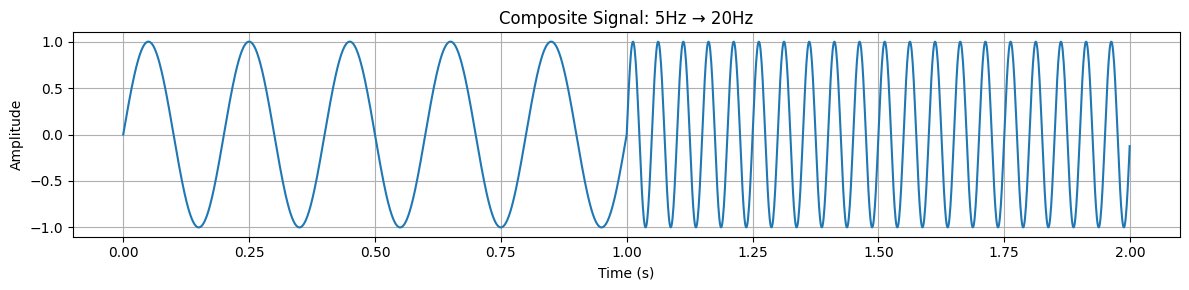

In [24]:
# Part 1: Visualize Spectrogram of a Composite Signal
# We'll create a signal that changes frequency over time (a "chirp").

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Sampling setup
fs = 1000
t = np.linspace(0, 2, 2 * fs, endpoint=False)  # 2 seconds

# Composite signal: 5 Hz for 1s, 20 Hz for next 1s
signal = np.concatenate([
    np.sin(2 * np.pi * 5 * t[:fs]),
    np.sin(2 * np.pi * 20 * t[fs:])
])

# Plot raw signal
plt.figure(figsize=(12, 3))
plt.plot(t, signal)
plt.title("Composite Signal: 5Hz → 20Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


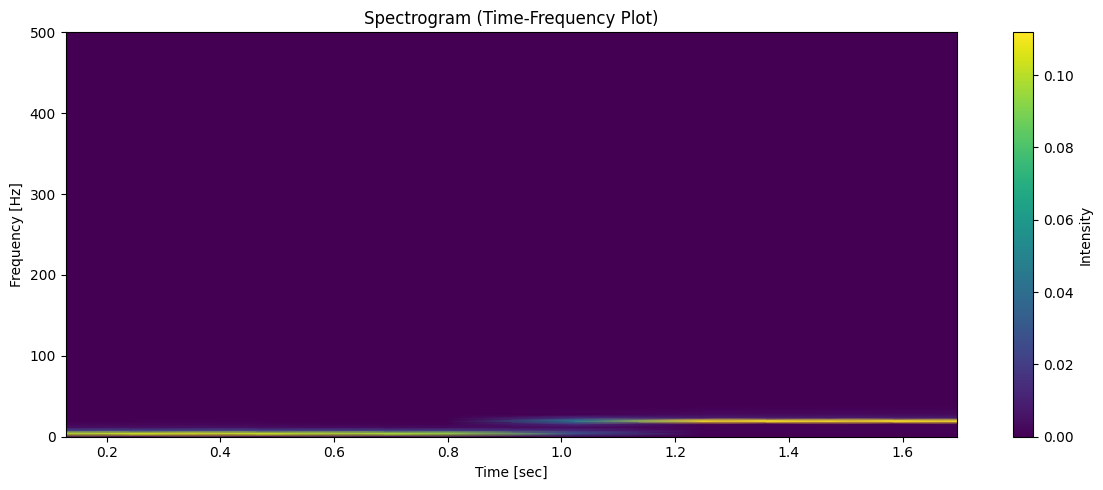

In [25]:
# Part 2: Spectrogram using scipy.signal.spectrogram

f, tt, Sxx = spectrogram(signal, fs)

plt.figure(figsize=(12, 5))
plt.pcolormesh(tt, f, Sxx, shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title("Spectrogram (Time-Frequency Plot)")
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()


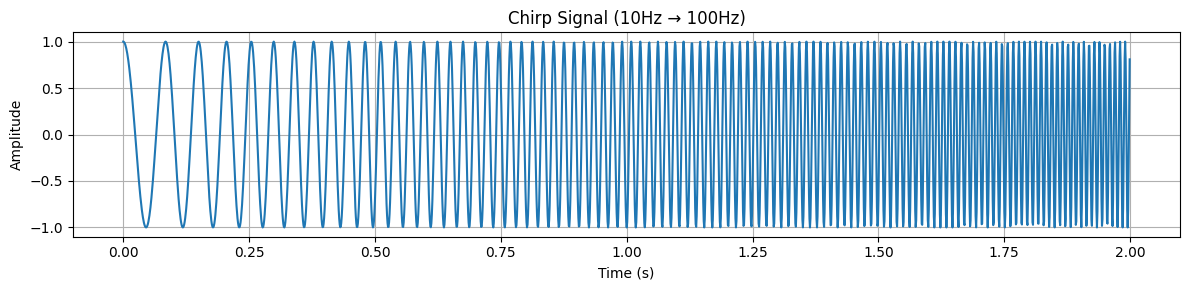

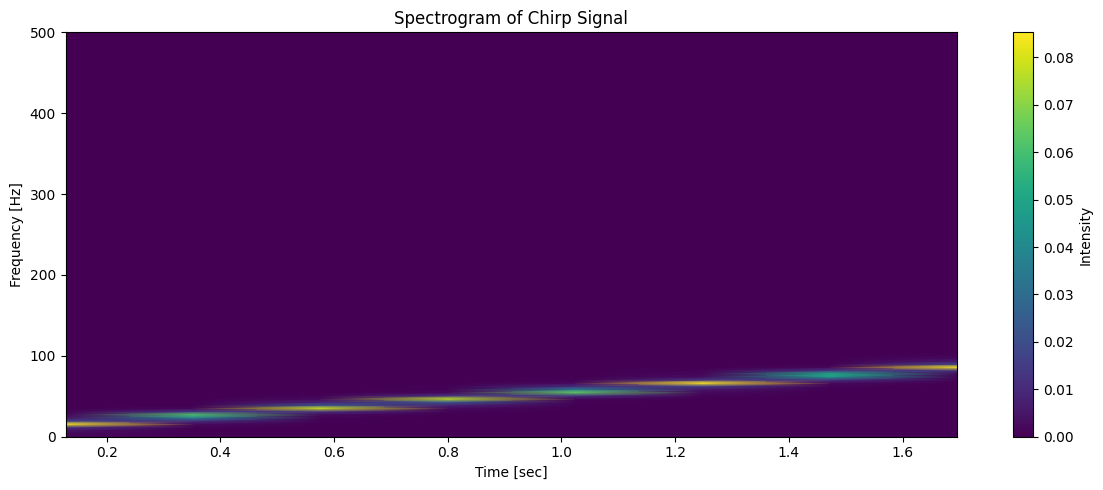

In [26]:
# Part 3: Try Spectrogram of a Chirp Signal (sweeping frequency)

from scipy.signal import chirp

# Chirp: frequency increases linearly from 10Hz to 100Hz over 2 seconds
chirp_signal = chirp(t, f0=10, f1=100, t1=2, method='linear')

# Plot chirp
plt.figure(figsize=(12, 3))
plt.plot(t, chirp_signal)
plt.title("Chirp Signal (10Hz → 100Hz)")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

# Spectrogram of chirp
f, tt, Sxx = spectrogram(chirp_signal, fs)

plt.figure(figsize=(12, 5))
plt.pcolormesh(tt, f, Sxx, shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title("Spectrogram of Chirp Signal")
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()
